Group name: Stock Success
Created by Lexinejazly Asuncion (017077242), Pranavi Immanni (017207554), Anika Manjesh (017808479)

In [51]:
!pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

## **Import Data and Preprocessing**

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tech
apple_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/apple.csv'
nvidia_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/nvidia.csv'
microsoft_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/microsoft.csv'

# Defense
lockheed_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/lockheedmartin.csv'
northrop_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/northropgrumman.csv'
boeing_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/boeing.csv.zip'

# Waste Management
waste_mgt_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wastemanagementinc.csv'
republic_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/republicservices.csv'
waste_conn_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wasteconnections.csv'

In [54]:
url_list = {
    'AAPL': apple_url,
    'NVDA': nvidia_url,
    'MSFT': microsoft_url,
    'LMT': lockheed_url,
    'NOC': northrop_url,
    'BA': boeing_url,
    'WM': waste_mgt_url,
    'RSG': republic_url,
    'WCN': waste_conn_url
}

all_frames = []

rename_map = {
    'date': 'Date',
    'price': 'Close',
    'Price': 'Close',
    'Close/Last': 'Close',
    'close': 'Close',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'volume': 'Volume',
    'Vol.': 'Volume',
    'adj_close': 'Adj Close'
}

tech_tickers = ['AAPL', 'NVDA', 'MSFT']
defense_tickers = ['LMT', 'NOC', 'BA']
waste_tickers = ['WM', 'RSG', 'WCN']

#read csv files and store data into one dataframe
for name, url in url_list.items():
    df = pd.read_csv(url,
                     na_values=["-", ""])

    df.columns = [col.strip() for col in df.columns]

    df = df.rename(columns=rename_map)
    
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.date

    df['Ticker'] = name

    #create column 'Industry' that specifies the industry
    if name in tech_tickers:
        df['Industry'] = 'Tech'
    elif name in defense_tickers:
        df['Industry'] = 'Defense'
    elif name in waste_tickers:
        df['Industry'] = 'Waste Management'

    #keep only the columns that exist in almost all sets
    standard_cols = ['Industry', 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[standard_cols]

    all_frames.append(df)

#merge the dataframes into one
stocks = pd.concat(all_frames, ignore_index=True)

In [55]:
#clean 'Volume', 'Open', 'High', 'Low', and 'Close' columns
stocks['Volume'] = pd.to_numeric(stocks['Volume'].astype(str).str.replace('M', 'e6').str.replace('K', 'e3').str.replace('B', 'e9'), errors='coerce')

numeric_cols = ['Open', 'High', 'Low', 'Close']

for col in numeric_cols:
    stocks[col] = pd.to_numeric(
        stocks[col].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')
     

In [56]:
stocks.head()

,Industry,Date,Ticker,Open,High,Low,Close,Volume
0,Tech,2025-09-26,AAPL,254.10,257.60,253.78,255.46,46080000.0
1,Tech,2025-09-25,AAPL,253.21,257.17,251.71,256.87,55200000.0
2,Tech,2025-09-24,AAPL,255.22,255.74,251.04,252.31,42300000.0
3,Tech,2025-09-23,AAPL,255.88,257.34,253.58,254.43,60280000.0
4,Tech,2025-09-22,AAPL,248.30,256.64,248.12,256.08,105520000.0


In [57]:
stocks.describe()

,Open,High,Low,Close,Volume
count,53011.000000,53011.000000,53011.000000,53011.000000,5.301000e+04
mean,91.936971,92.837901,91.026213,91.950703,1.187463e+08
std,118.605668,119.735844,117.456046,118.614944,2.814343e+08
min,0.060833,0.065667,0.060000,0.061417,7.290000e+04
25%,5.664032,5.728395,5.574074,5.656250,1.366203e+06
50%,43.920000,44.437500,43.312500,43.937500,3.732000e+06
75%,131.250000,132.430000,129.762500,131.135002,6.825630e+07
max,768.850000,774.000000,751.870000,768.020000,9.230856e+09


In [58]:
stocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 53011 entries, 0 to 53010
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Industry  53011 non-null  str    
 1   Date      53011 non-null  object 
 2   Ticker    53011 non-null  str    
 3   Open      53011 non-null  float64
 4   High      53011 non-null  float64
 5   Low       53011 non-null  float64
 6   Close     53011 non-null  float64
 7   Volume    53010 non-null  float64
dtypes: float64(5), object(1), str(2)
memory usage: 3.2+ MB


There is missing data for one data entry in the stocks dataframe that corresponds to the Volume column. Since there is only one missing data point, we can remove it.

In [59]:
stocks[stocks['Volume'].isna()]

,Industry,Date,Ticker,Open,High,Low,Close,Volume
52964,Waste Management,2016-06-01,WCN,43.766,43.766,43.766,43.766,NaN


In [60]:
stocks.drop(index=52964, inplace=True)

In [61]:
stocks.info()

<class 'pandas.DataFrame'>
Index: 53010 entries, 0 to 53010
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Industry  53010 non-null  str    
 1   Date      53010 non-null  object 
 2   Ticker    53010 non-null  str    
 3   Open      53010 non-null  float64
 4   High      53010 non-null  float64
 5   Low       53010 non-null  float64
 6   Close     53010 non-null  float64
 7   Volume    53010 non-null  float64
dtypes: float64(5), object(1), str(2)
memory usage: 3.6+ MB


## **Exploratory Data Analysis**

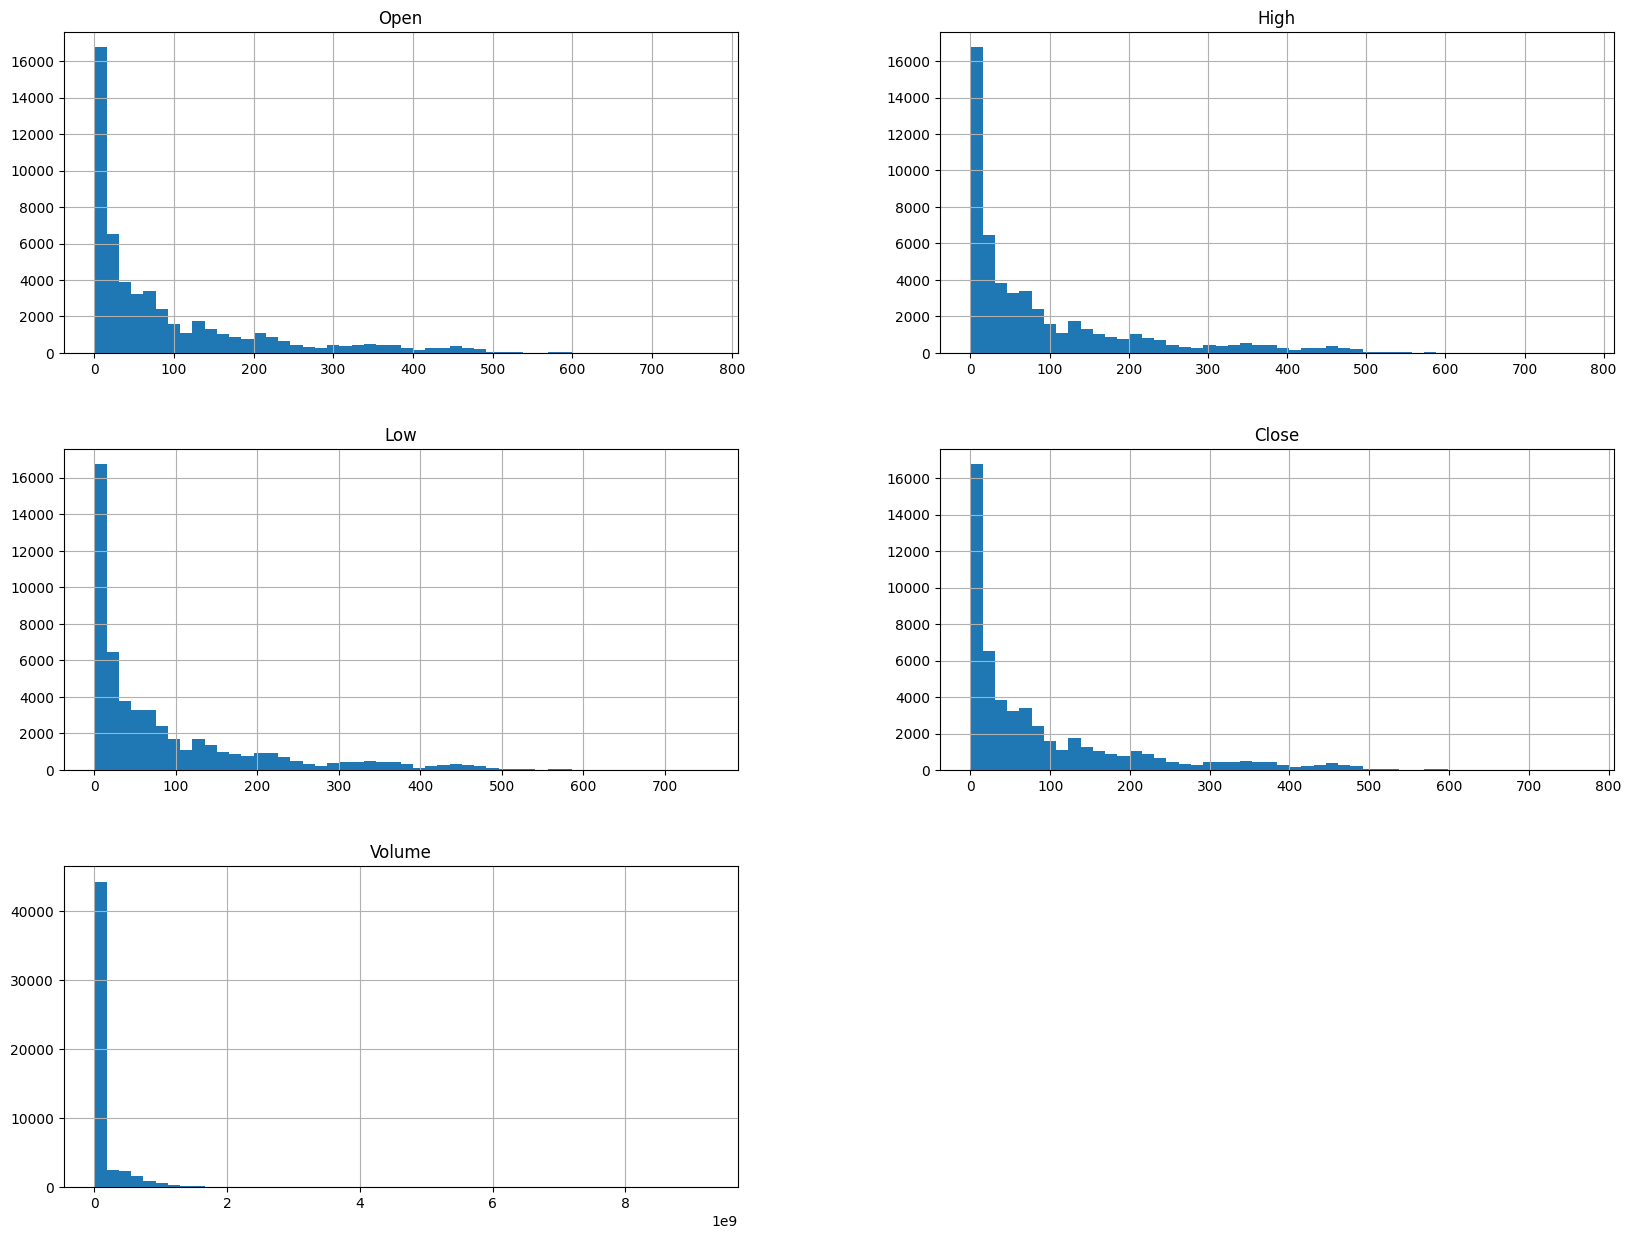

In [62]:
%matplotlib inline
import matplotlib.pyplot as plt
stocks.hist(bins=50, figsize=(20,15));

## **Interactive Plot**

# **Machine Learning**

Step 1

In [63]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


For our data, we are choosing to use regression models because classification models are for discrete data and our data is continuous.

In [64]:
stocks = stocks.sort_values(["Ticker", "Date"])

stocks["Return"] = stocks.groupby("Ticker")["Close"].pct_change()

# predict next day's return
stocks["Target"] = stocks.groupby("Ticker")["Return"].shift(-1)

In [65]:
stocks["Target"] = (stocks.groupby("Ticker")["Close"].pct_change().shift(-1) > 0).astype(int)

In [66]:
stocks["Date"] = pd.to_datetime(stocks["Date"], errors="coerce")
stocks = stocks.sort_values(["Ticker", "Date"]).reset_index(drop=True)

stocks["Return"] = stocks.groupby("Ticker")["Close"].pct_change()
stocks["MA_5"] = stocks.groupby("Ticker")["Close"].transform(lambda s: s.rolling(5).mean())
stocks["MA_20"] = stocks.groupby("Ticker")["Close"].transform(lambda s: s.rolling(20).mean())
stocks["Volatility_5"] = stocks.groupby("Ticker")["Return"].transform(lambda s: s.rolling(5).std())
stocks["Range"] = stocks["High"] - stocks["Low"]
stocks["Volume_Change"] = stocks.groupby("Ticker")["Volume"].pct_change()

# classification target: will tomorrow be positive?
stocks["Target"] = (stocks.groupby("Ticker")["Return"].shift(-1) > 0).astype(int)

stocks = stocks.dropna(subset=["Return", "MA_5", "MA_20", "Volatility_5", "Volume_Change"]).copy()

In [67]:
train = stocks[stocks["Date"] < pd.Timestamp("2020-01-01")].copy()
test  = stocks[stocks["Date"] >= pd.Timestamp("2020-01-01")].copy()

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "MA_5", "MA_20", "Volatility_5", "Range", "Volume_Change"
]
cat_features = ["Ticker", "Industry"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [70]:
pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

In [ ]:
from sklearn.model_selection import cross_val_score

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, train[num_features + cat_features], train["Target"],
                             cv=5, scoring="f1")
    print(name)
    print("F1 scores:", scores)
    print("Mean F1:", scores.mean())
    print()

Random Forest is found to be the best classification model for our purposes since it has the highest Mean F1 score. 

In [ ]:
best_model = pipelines["Random Forest"] 
best_model.fit(train[num_features + cat_features], train["Target"])

y_test = test["Target"]
y_pred = best_model.predict(test[num_features + cat_features])
y_prob = best_model.predict_proba(test[num_features + cat_features])[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
feature_cols_num = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "MA_5", "MA_20", "Volatility_5", "Range", "Volume_Change"
]

feature_cols_cat = ["Ticker", "Industry"]

X_train = train[feature_cols_num + feature_cols_cat]
y_train = train["Target"]

X_test = test[feature_cols_num + feature_cols_cat]
y_test = test["Target"]

In [ ]:
best_model = pipelines["Random Forest"]

best_model.fit(X_train, y_train)

In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
test_results = test.copy()
test_results["Predicted"] = y_pred
test_results["Prob_Up"] = y_prob

In [ ]:
industry_summary = test_results.groupby("Industry").agg(
    Avg_Prob_Up=("Prob_Up", "mean"),
    Actual_Up_Rate=("Target", "mean")
).reset_index().sort_values("Avg_Prob_Up", ascending=False)

print(industry_summary)

In [ ]:
stock_summary = test_results.groupby(["Ticker", "Industry"]).agg(
    Avg_Prob_Up=("Prob_Up", "mean"),
    Actual_Up_Rate=("Target", "mean")
).reset_index().sort_values("Avg_Prob_Up", ascending=False)

print(stock_summary)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(industry_summary["Industry"], industry_summary["Avg_Prob_Up"])
plt.title("Predicted Probability of Positive Returns (2020)")
plt.ylabel("Probability")
plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix (2020)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
worst_stocks = test_results.groupby("Ticker").agg(
    Avg_Return=("Return", "mean")
).sort_values("Avg_Return")

print(worst_stocks.head())

In [ ]:
before = stocks[stocks["Date"] < "2020-01-01"]
during = test
after = stocks[stocks["Date"] > "2020-12-31"]

In [ ]:
print("Before:\n", before.groupby("Industry")["Return"].mean())
print("\nDuring:\n", during.groupby("Industry")["Return"].mean())
print("\nAfter:\n", after.groupby("Industry")["Return"].mean())

In [ ]:
df = stocks.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

In [ ]:
import pandas as pd
import numpy as np

def engineer_features(df):
    df = df.sort_values(['Ticker', 'Date']).copy()
    g = df.groupby('Ticker')['Close']

    # Returns
    df['Return_1D']  = g.pct_change(1)
    df['Return_5D']  = g.pct_change(5)
    df['Return_20D'] = g.pct_change(20)
    df['Return_60D'] = g.pct_change(60)

    # Moving averages
    roll = lambda x, n: x.rolling(n).mean()
    df['MA_20']  = g.transform(roll, 20)
    df['MA_50']  = g.transform(roll, 50)
    df['MA_200'] = g.transform(roll, 200)
    df['Price_to_MA50'] = df['Close'] / df['MA_50']
    df['MA50_to_MA200'] = df['MA_50'] / df['MA_200']

    # Volatility
    ret_g = df.groupby('Ticker')['Return_1D']
    df['Volatility_20D'] = ret_g.transform(lambda x: x.rolling(20).std())
    df['Volatility_60D'] = ret_g.transform(lambda x: x.rolling(60).std())

    # Volume ratio
    vol_ma = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
    df['Volume_Ratio'] = df['Volume'] / vol_ma

    # RSI (14-day)
    def rsi(series, n=14):
        d = series.diff()
        gain = d.clip(lower=0).rolling(n).mean()
        loss = (-d.clip(upper=0)).rolling(n).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    df['RSI_14'] = g.transform(rsi)

    # Bollinger Band position
    std = g.transform(lambda x: x.rolling(20).std())
    df['BB_Position'] = (df['Close'] - df['MA_20']) / (2 * std)

    return df


def add_recession_features(df):
    df = df.copy()

    REC_START = pd.Timestamp('2020-02-01')
    REC_END   = pd.Timestamp('2020-04-30')
    REC_RCVY  = pd.Timestamp('2020-12-31')

    rec  = df[(df['Date'] >= REC_START) & (df['Date'] <= REC_END)]
    pre  = df[df['Date'] < REC_START]
    rcvy = df[(df['Date'] > REC_END) & (df['Date'] <= REC_RCVY)]

    drawdown = (
        rec.groupby('Ticker')['Close']
        .apply(lambda x: (x / x.cummax() - 1).min())
        .rename('Recession_MaxDrawdown')
    )

    trough = rec.groupby('Ticker')['Close'].min()
    rec_last = rcvy.groupby('Ticker')['Close'].last()
    recovery = ((rec_last - trough) / trough).rename('Recovery_Return')

    vol_spike = (
        rec.groupby('Ticker')['Volume'].mean() /
        pre.groupby('Ticker')['Volume'].mean()
    ).rename('Recession_VolSpike')

    stats = pd.concat([drawdown, recovery, vol_spike], axis=1).reset_index()
    df = df.merge(stats, on='Ticker', how='left')

    df['In_Recession'] = (
        (df['Date'] >= REC_START) & (df['Date'] <= REC_END)
    ).astype(int)

    return df

In [ ]:
def create_labels(df, forward_days=20, buy_threshold=0.05):
    df = df.sort_values(['Ticker', 'Date']).copy()

    future_close = df.groupby('Ticker')['Close'].shift(-forward_days)
    forward_return = (future_close - df['Close']) / df['Close']

    df['Forward_Return'] = forward_return
    df['Target'] = (df['Forward_Return'] >= buy_threshold).astype(int)

    return df

In [ ]:
def temporal_split(df, split_date='2020-01-01'):
    train = df[df['Date'] < pd.Timestamp(split_date)].copy()
    test  = df[df['Date'] >= pd.Timestamp(split_date)].copy()

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Return_1D', 'Return_5D', 'Return_20D', 'Return_60D',
        'MA_20', 'MA_50', 'MA_200',
        'Price_to_MA50', 'MA50_to_MA200',
        'Volatility_20D', 'Volatility_60D',
        'Volume_Ratio', 'RSI_14', 'BB_Position',
        'Recession_MaxDrawdown', 'Recovery_Return',
        'Recession_VolSpike', 'In_Recession',
        'Ticker', 'Industry'
    ]

    train = train.dropna(subset=feature_cols + ['Target'])
    test  = test.dropna(subset=feature_cols + ['Target'])

    X_train = train[feature_cols]
    y_train = train['Target']
    X_test = test[feature_cols]
    y_test = test['Target']

    return X_train, X_test, y_train, y_test, train, test, feature_cols

In [ ]:
df = stocks.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df = engineer_features(df)
df = add_recession_features(df)
df = create_labels(df, forward_days=20, buy_threshold=0.05)

X_train, X_test, y_train, y_test, train_df, test_df, feature_cols = temporal_split(df)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Return_1D', 'Return_5D', 'Return_20D', 'Return_60D',
    'MA_20', 'MA_50', 'MA_200',
    'Price_to_MA50', 'MA50_to_MA200',
    'Volatility_20D', 'Volatility_60D',
    'Volume_Ratio', 'RSI_14', 'BB_Position',
    'Recession_MaxDrawdown', 'Recovery_Return',
    'Recession_VolSpike', 'In_Recession'
]

cat_features = ['Ticker', 'Industry']

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

results = []

for name, pipe in pipelines.items():
    cv = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1"]
    )

    results.append({
        "Model": name,
        "CV Accuracy": cv["test_accuracy"].mean(),
        "CV Precision": cv["test_precision"].mean(),
        "CV Recall": cv["test_recall"].mean(),
        "CV F1": cv["test_f1"].mean()
    })

results_df = pd.DataFrame(results).sort_values("CV F1", ascending=False)
print(results_df)

In [ ]:
best_model = pipelines["Random Forest"]
best_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
latest_rows = df.sort_values("Date").groupby("Ticker").tail(1).copy()
latest_rows = latest_rows.dropna(subset=feature_cols)

latest_probs = best_model.predict_proba(latest_rows[feature_cols])[:, 1]
latest_rows["Buy_Probability"] = latest_probs

recommendations = latest_rows[["Ticker", "Industry", "Date", "Buy_Probability"]]
recommendations = recommendations.sort_values("Buy_Probability", ascending=False)

print(recommendations)

## **Evaluation**